# Model Evaluation — REPSOL Industrial Sound Classification

Evaluate and compare all trained models on the REPSOL test set (297 samples, 8 classes).

**⚠ Dataset update:** all models below train and evaluate on the **fixed dataset**
`Data/Spectrograms_224` — the plot interior of each spectrogram figure, resized to 224×224.
Earlier runs (EfficientNet-01/02/03, ResNet50-01, MobileNetV3-01) used a broken view of the
data (the first 400 of 3,156 pixel columns of full-figure renders, ≈13% of the spectrogram);
their recorded results are kept in the **Historical runs** section for reference and are NOT
re-evaluated here.

**Models compared (live, on fixed data):**
- `MobileNetV3_02` — full anti-overfitting package (SpecAugment, partial freeze, macro-F1 checkpointing)
- `EfficientNet_04` — same package on EfficientNet-B0
- `EfficientNet_05` — ablation control: run-02 baseline config on fixed data (no augmentation/freeze)
- `ResNet50_02` — same package, layer4+fc trainable only
- `PreTrained_02` — Watkins bioacoustics warm-start + full package (failed transfer — kept for analysis)

**Metrics:**
- Accuracy, balanced accuracy, MCC (Matthews correlation — robust single score under imbalance)
- Precision / Recall / F1 (weighted & macro), Top-2 accuracy
- Per-class Precision / Recall / F1 / one-vs-rest AUC
- Confusion matrices (counts + normalised), ROC curves per class
- Per-class F1 heatmap + delta vs best model
- Confidence distributions, learning curves, misclassification analysis
- Model agreement: universally-hard samples + oracle ensemble ceiling
- Historical (broken-data) runs table + final verdict & decision guide

**Caching:** inference results are stored in `outputs/evaluation/cache/{ModelName}.npz`.
Re-running the notebook loads the cache instantly. Set `FORCE_RERUN = True` after retraining a model
(or delete its `.npz` file) to refresh its results.

## 0. Setup

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path(r"D:\Work\Internships\INMAR\REPSOL")
sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "src"))

# ── Set to True to re-run inference even if cache exists ──
FORCE_RERUN = False

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    confusion_matrix, classification_report,
    roc_auc_score, ConfusionMatrixDisplay,
)
from sklearn.preprocessing import label_binarize

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
print(f"Repo root: {REPO_ROOT}")

Device: cpu
Repo root: D:\Work\Internships\INMAR\REPSOL


## 1. Paths

In [2]:
SPECT_DIR     = REPO_ROOT / "Data" / "Spectrograms_224"   # fixed dataset (full spectrogram, 224x224)
MODELS_OUTPUT = REPO_ROOT / "Models_output"
EVAL_OUT      = REPO_ROOT / "outputs" / "evaluation"
CACHE_DIR     = EVAL_OUT / "cache"
EVAL_OUT.mkdir(parents=True, exist_ok=True)
CACHE_DIR.mkdir(parents=True, exist_ok=True)

# ── Add/remove checkpoints here ──
# Missing checkpoints are skipped automatically.
CHECKPOINTS = {
    "MobileNetV3_02":  MODELS_OUTPUT / "mobilenetv3_02_best_01.pth",
    "EfficientNet_04": MODELS_OUTPUT / "efficientnet_04_best_01.pth",
    "EfficientNet_05": MODELS_OUTPUT / "efficientnet_05_best_01.pth",
    "ResNet50_02":     MODELS_OUTPUT / "resnet50_02_best_01.pth",
    "PreTrained_02":   MODELS_OUTPUT / "pretrained_02_best_01.pth",
}

# model_name passed to the model factory for each checkpoint
MODEL_TYPES = {
    "MobileNetV3_02":  "mobilenetv3",
    "EfficientNet_04": "efficientnet",
    "EfficientNet_05": "efficientnet",
    "ResNet50_02":     "resnet50",
    "PreTrained_02":   "efficientnet",   # same architecture, Watkins-initialised
}

HISTORIES = {
    "MobileNetV3_02":  MODELS_OUTPUT / "mobilenetv3_02_best_01_training_history.csv",
    "EfficientNet_04": MODELS_OUTPUT / "efficientnet_04_best_01_training_history.csv",
    "EfficientNet_05": MODELS_OUTPUT / "efficientnet_05_best_01_training_history.csv",
    "ResNet50_02":     MODELS_OUTPUT / "resnet50_02_best_01_training_history.csv",
    "PreTrained_02":   MODELS_OUTPUT / "pretrained_02_best_01_training_history.csv",
}

print("Checkpoints:")
for name, path in CHECKPOINTS.items():
    status = "✓" if path.exists() else "✗ MISSING (will skip)"
    print(f"  {status}  {name}: {path.name}")

print("\nCache files:")
for name in CHECKPOINTS:
    cache = CACHE_DIR / f"{name}.npz"
    status = "cached" if cache.exists() else "not cached"
    print(f"  {name}: {status}")

Checkpoints:
  ✓  MobileNetV3_02: mobilenetv3_02_best_01.pth
  ✓  EfficientNet_04: efficientnet_04_best_01.pth
  ✓  EfficientNet_05: efficientnet_05_best_01.pth
  ✓  ResNet50_02: resnet50_02_best_01.pth
  ✓  PreTrained_02: pretrained_02_best_01.pth

Cache files:
  MobileNetV3_02: not cached
  EfficientNet_04: not cached
  EfficientNet_05: not cached
  ResNet50_02: not cached
  PreTrained_02: not cached


## 2. Load Test DataLoader

In [3]:
from src.dataloaders import get_dataloaders

_, _, test_loader = get_dataloaders(
    SPECT_DIR, batch_size=32, num_workers=0, pin_memory=False, persistent_workers=False,
    target_width=None,   # 224x224 tensors are already model-ready — no pad/crop
)

CLASS_NAMES = test_loader.dataset.classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Test samples : {len(test_loader.dataset)}")
print(f"Classes ({NUM_CLASSES}):")
for i, c in enumerate(CLASS_NAMES):
    print(f"  {i}: {c}")

Test samples : 297
Classes (8):
  0: 0 ActividadBASE_NO pattern activity
  1: 1 Pulses HAMMERING
  2: 2 Marked cycles 3 segundos
  3: 3 Continuous activity & tone 3.15kHz_SPL ALTO
  4: 4 Continuous activity & tone 3.15kHz_ SPL BAJO
  5: 5 Blasts
  6: 6 Machinery continuous activity
  7: 7 Works_ sirens and knocks en altas frecuencias RAFAGAS a 3.15


## 3. Inference + Caching

In [4]:
from src.PreTrained_model.load_pretrained import load_model as load_efficientnet


def _load_model_for_eval(name, ckpt_path, model_type, num_classes, device):
    """Load the right model class depending on model_type."""
    if model_type in ("efficientnet", "efficientnet_b0", "b0"):
        model, _ = load_efficientnet(
            checkpoint_path=str(ckpt_path),
            model_name="efficientnet",
            num_classes=num_classes,
            device=device,
        )
        return model
    elif model_type in ("resnet50", "resnet", "r50"):
        from src.ResNet.model import get_model as get_resnet
        model = get_resnet(model_name="resnet50", num_classes=num_classes).to(device)
        state = torch.load(str(ckpt_path), map_location=device)
        model.load_state_dict(state)
        model.eval()
        return model
    elif model_type in ("mobilenet", "mobilenetv3", "mobilenet_v3", "v3"):
        from src.MobileNet.model import get_model as get_mobilenet
        model = get_mobilenet(model_name="mobilenetv3", num_classes=num_classes).to(device)
        state = torch.load(str(ckpt_path), map_location=device)
        model.load_state_dict(state)
        model.eval()
        return model
    else:
        raise ValueError(f"Unknown model_type: {model_type!r}")


def run_inference(model, loader, device):
    model.eval()
    all_true, all_pred, all_probs = [], [], []
    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            probs = torch.softmax(model(x), dim=1).cpu().numpy()
            all_true.extend(y.numpy())
            all_pred.extend(probs.argmax(1))
            all_probs.append(probs)
    return np.array(all_true), np.array(all_pred), np.vstack(all_probs)


def load_or_run(name, ckpt_path, model_type, loader, num_classes, device, force=False):
    cache_path = CACHE_DIR / f"{name}.npz"

    if not force and cache_path.exists():
        print(f"  [{name}] Loading from cache: {cache_path.name}")
        data = np.load(cache_path)
        return data["y_true"], data["y_pred"], data["y_probs"]

    print(f"  [{name}] Running inference ...")
    model = _load_model_for_eval(name, ckpt_path, model_type, num_classes, device)
    y_true, y_pred, y_probs = run_inference(model, loader, device)
    del model  # free memory
    np.savez_compressed(cache_path, y_true=y_true, y_pred=y_pred, y_probs=y_probs)
    print(f"  [{name}] Saved to cache: {cache_path.name}")
    return y_true, y_pred, y_probs


# ── Run / load all models ──
raw_results = {}
for model_name, ckpt_path in CHECKPOINTS.items():
    if not ckpt_path.exists():
        print(f"  [{model_name}] Skipping — checkpoint not found")
        continue
    y_true, y_pred, y_probs = load_or_run(
        model_name, ckpt_path, MODEL_TYPES[model_name],
        test_loader, NUM_CLASSES, DEVICE, force=FORCE_RERUN,
    )
    raw_results[model_name] = (y_true, y_pred, y_probs)

print("\nReady:", list(raw_results.keys()))

  [MobileNetV3_02] Running inference ...
  [MobileNetV3_02] Saved to cache: MobileNetV3_02.npz
  [EfficientNet_04] Running inference ...
  [EfficientNet_04] Saved to cache: EfficientNet_04.npz
  [EfficientNet_05] Running inference ...
  [EfficientNet_05] Saved to cache: EfficientNet_05.npz
  [ResNet50_02] Running inference ...
  [ResNet50_02] Saved to cache: ResNet50_02.npz
  [PreTrained_02] Running inference ...
  [PreTrained_02] Saved to cache: PreTrained_02.npz

Ready: ['MobileNetV3_02', 'EfficientNet_04', 'EfficientNet_05', 'ResNet50_02', 'PreTrained_02']


## 4. Compute Metrics

In [5]:
from sklearn.metrics import matthews_corrcoef, balanced_accuracy_score


def compute_metrics(y_true, y_pred, y_probs, class_names):
    n = len(class_names)
    acc = accuracy_score(y_true, y_pred)
    bal_acc = balanced_accuracy_score(y_true, y_pred)  # mean per-class recall — robust to imbalance
    mcc = matthews_corrcoef(y_true, y_pred)            # -1..1, robust single-number quality score
    pw, rw, f1w, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    pm, rm, f1m, _ = precision_recall_fscore_support(y_true, y_pred, average="macro",    zero_division=0)
    top2 = sum(y_true[i] in np.argsort(y_probs[i])[-2:] for i in range(len(y_true))) / len(y_true)

    y_bin = label_binarize(y_true, classes=range(n))
    try:
        auc_macro = roc_auc_score(y_bin, y_probs, average="macro", multi_class="ovr")
    except Exception:
        auc_macro = float("nan")

    # per-class one-vs-rest AUC
    auc_per_class = []
    for i in range(n):
        try:
            auc_per_class.append(roc_auc_score(y_bin[:, i], y_probs[:, i]))
        except Exception:
            auc_per_class.append(float("nan"))

    max_conf     = y_probs.max(axis=1)
    correct_mask = y_true == y_pred
    prec_pc, rec_pc, f1_pc, sup_pc = precision_recall_fscore_support(
        y_true, y_pred, average=None, zero_division=0, labels=range(n)
    )
    per_class_df = pd.DataFrame({
        "class":     class_names,
        "precision": prec_pc, "recall": rec_pc, "f1": f1_pc,
        "auc":       auc_per_class,
        "support":   sup_pc.astype(int),
    })
    return {
        "accuracy": acc, "balanced_accuracy": bal_acc, "mcc": mcc,
        "precision_weighted": pw, "recall_weighted": rw, "f1_weighted": f1w,
        "precision_macro": pm, "recall_macro": rm, "f1_macro": f1m,
        "top2_accuracy": top2, "roc_auc_macro": auc_macro,
        "mean_conf_correct": max_conf[correct_mask].mean() if correct_mask.any() else float("nan"),
        "mean_conf_wrong":   max_conf[~correct_mask].mean() if (~correct_mask).any() else float("nan"),
        "per_class": per_class_df,
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=range(n)),
        "y_true": y_true, "y_pred": y_pred, "y_probs": y_probs,
    }


results = {
    name: compute_metrics(yt, yp, ypr, CLASS_NAMES)
    for name, (yt, yp, ypr) in raw_results.items()
}
print("Metrics computed for:", list(results.keys()))

Metrics computed for: ['MobileNetV3_02', 'EfficientNet_04', 'EfficientNet_05', 'ResNet50_02', 'PreTrained_02']


## 5. Summary Table

In [6]:
SCALAR_KEYS = [
    "accuracy", "balanced_accuracy", "mcc",
    "precision_weighted", "recall_weighted", "f1_weighted",
    "precision_macro", "recall_macro", "f1_macro",
    "top2_accuracy", "roc_auc_macro", "mean_conf_correct", "mean_conf_wrong",
]

summary = pd.DataFrame(
    {name: {k: m[k] for k in SCALAR_KEYS} for name, m in results.items()}
).T.round(4)

# Rank models by macro F1 (fairest single number under class imbalance)
summary = summary.sort_values("f1_macro", ascending=False)
print(f"Best model by macro F1: {summary.index[0]}\n")

# Highlight the best value in each column
display(summary.style.highlight_max(axis=0, color="#c6efce"))

Best model by macro F1: MobileNetV3_02



,accuracy,balanced_accuracy,mcc,precision_weighted,recall_weighted,f1_weighted,precision_macro,recall_macro,f1_macro,top2_accuracy,roc_auc_macro,mean_conf_correct,mean_conf_wrong
MobileNetV3_02,0.865300,0.856100,0.826600,0.871100,0.865300,0.866700,0.815400,0.856100,0.828300,0.919200,0.977900,0.591400,0.461200
EfficientNet_05,0.811400,0.816200,0.759600,0.822600,0.811400,0.813800,0.823900,0.816200,0.816300,0.952900,0.962900,0.966500,0.821500
EfficientNet_04,0.831600,0.800200,0.782700,0.840600,0.831600,0.834200,0.769800,0.800200,0.778400,0.909100,0.974100,0.616300,0.490800
ResNet50_02,0.808100,0.757600,0.754600,0.842200,0.808100,0.820700,0.733000,0.757600,0.725300,0.902400,0.963500,0.635500,0.519700
PreTrained_02,0.272700,0.370000,0.220200,0.620100,0.272700,0.258000,0.401700,0.370000,0.265500,0.444400,0.699700,0.299000,0.309000


## 5b. Historical runs (broken data) — recorded metrics

These runs trained on the broken data view (first 400/3,156 pixel columns of full-figure
renders) or, for PreTrained-01, were never trained on REPSOL data at all. Their numbers are
quoted from their notebooks' recorded outputs — re-evaluating those checkpoints on the fixed
dataset would be meaningless (wrong input distribution for what they learned).

In [7]:
historical = pd.DataFrame([
    {"model": "EfficientNet_01", "test_acc": 0.6768, "test_macro_f1": 0.625, "test_weighted_f1": 0.6548,
     "note": "broken data, baseline config"},
    {"model": "EfficientNet_02", "test_acc": 0.70,   "test_macro_f1": 0.59,  "test_weighted_f1": 0.69,
     "note": "broken data, baseline config (previous best)"},
    {"model": "EfficientNet_03a (squared weights)", "test_acc": np.nan, "test_macro_f1": np.nan, "test_weighted_f1": np.nan,
     "note": "training collapsed (val acc below majority baseline); aborted, never test-evaluated"},
    {"model": "EfficientNet_03b (boost + OneCycle)", "test_acc": np.nan, "test_macro_f1": np.nan, "test_weighted_f1": np.nan,
     "note": "best val acc 71.6% (ep13), then overfit to 99% train acc; stopped ep18, never test-evaluated"},
    {"model": "ResNet50_01", "test_acc": 0.6128, "test_macro_f1": 0.549, "test_weighted_f1": 0.6031,
     "note": "broken data; 25M params fully fine-tuned -> memorised training set"},
    {"model": "PreTrained_01 (Watkins zero-shot)", "test_acc": 0.0034, "test_macro_f1": 0.0, "test_weighted_f1": 0.0062,
     "note": "44-class marine-species model evaluated unchanged: disjoint class sets, invalid experiment"},
])

print(historical.to_string(index=False))

# ── Combined table: live (fixed data) + historical (broken data) ──
live_rows = pd.DataFrame([
    {"model": name,
     "test_acc": m["accuracy"],
     "test_macro_f1": m["f1_macro"],
     "test_weighted_f1": m["f1_weighted"],
     "note": "LIVE eval on fixed Data/Spectrograms_224"}
    for name, m in results.items()
])
combined = pd.concat([live_rows, historical], ignore_index=True)
combined = combined.sort_values(["test_macro_f1", "test_acc"], ascending=False, na_position="last")

print("\n================ ALL RUNS, RANKED BY TEST MACRO-F1 ================")
print(combined.round(4).to_string(index=False))
combined.to_csv(EVAL_OUT / "all_runs_summary.csv", index=False)
print(f"\nSaved -> {EVAL_OUT / 'all_runs_summary.csv'}")

                              model  test_acc  test_macro_f1  test_weighted_f1                                                                                         note
                    EfficientNet_01    0.6768          0.625            0.6548                                                                 broken data, baseline config
                    EfficientNet_02    0.7000          0.590            0.6900                                                 broken data, baseline config (previous best)
 EfficientNet_03a (squared weights)       NaN            NaN               NaN          training collapsed (val acc below majority baseline); aborted, never test-evaluated
EfficientNet_03b (boost + OneCycle)       NaN            NaN               NaN best val acc 71.6% (ep13), then overfit to 99% train acc; stopped ep18, never test-evaluated
                        ResNet50_01    0.6128          0.549            0.6031                           broken data; 25M params fully fine-

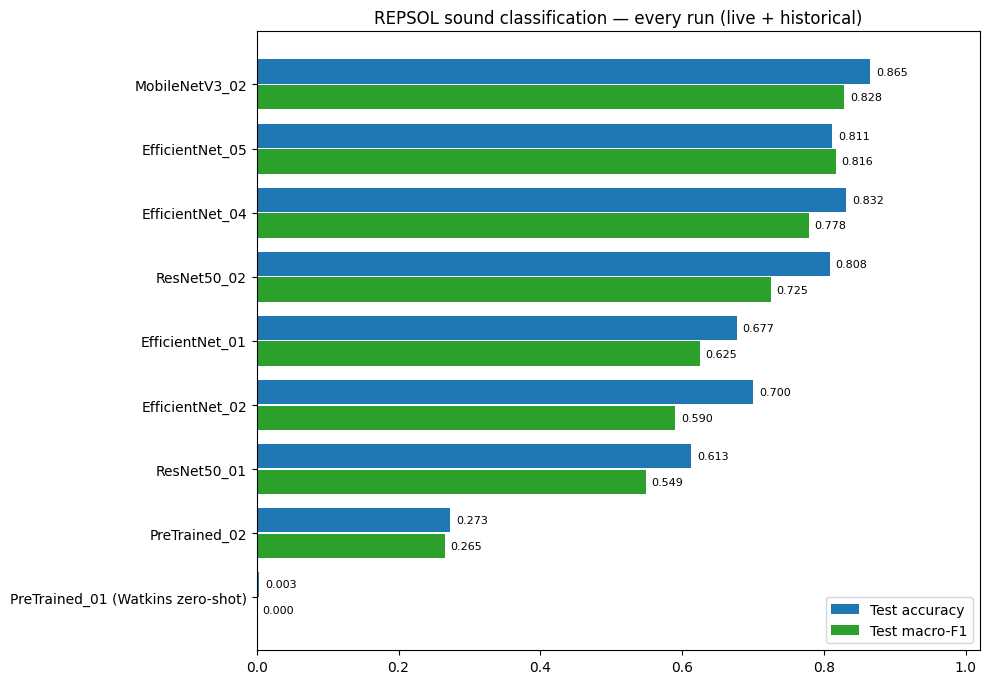

In [8]:
# ── All-runs bar chart: accuracy + macro-F1, live and historical together ──
plot_df = combined.dropna(subset=["test_acc"]).iloc[::-1]  # reversed for horizontal bars

fig, ax = plt.subplots(figsize=(10, 0.55 * len(plot_df) + 2))
ypos = np.arange(len(plot_df))
ax.barh(ypos + 0.2, plot_df["test_acc"],      height=0.38, label="Test accuracy", color="C0")
ax.barh(ypos - 0.2, plot_df["test_macro_f1"], height=0.38, label="Test macro-F1", color="C2")
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df["model"])
ax.set_xlim(0, 1.02)
ax.legend(loc="lower right")
ax.set_title("REPSOL sound classification — every run (live + historical)")
for yi, (acc, f1m) in enumerate(zip(plot_df["test_acc"], plot_df["test_macro_f1"])):
    ax.text(acc + 0.008, yi + 0.2, f"{acc:.3f}", va="center", fontsize=8)
    ax.text(f1m + 0.008, yi - 0.2, f"{f1m:.3f}", va="center", fontsize=8)
fig.tight_layout()
plt.savefig(EVAL_OUT / "all_runs_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Confusion Matrices

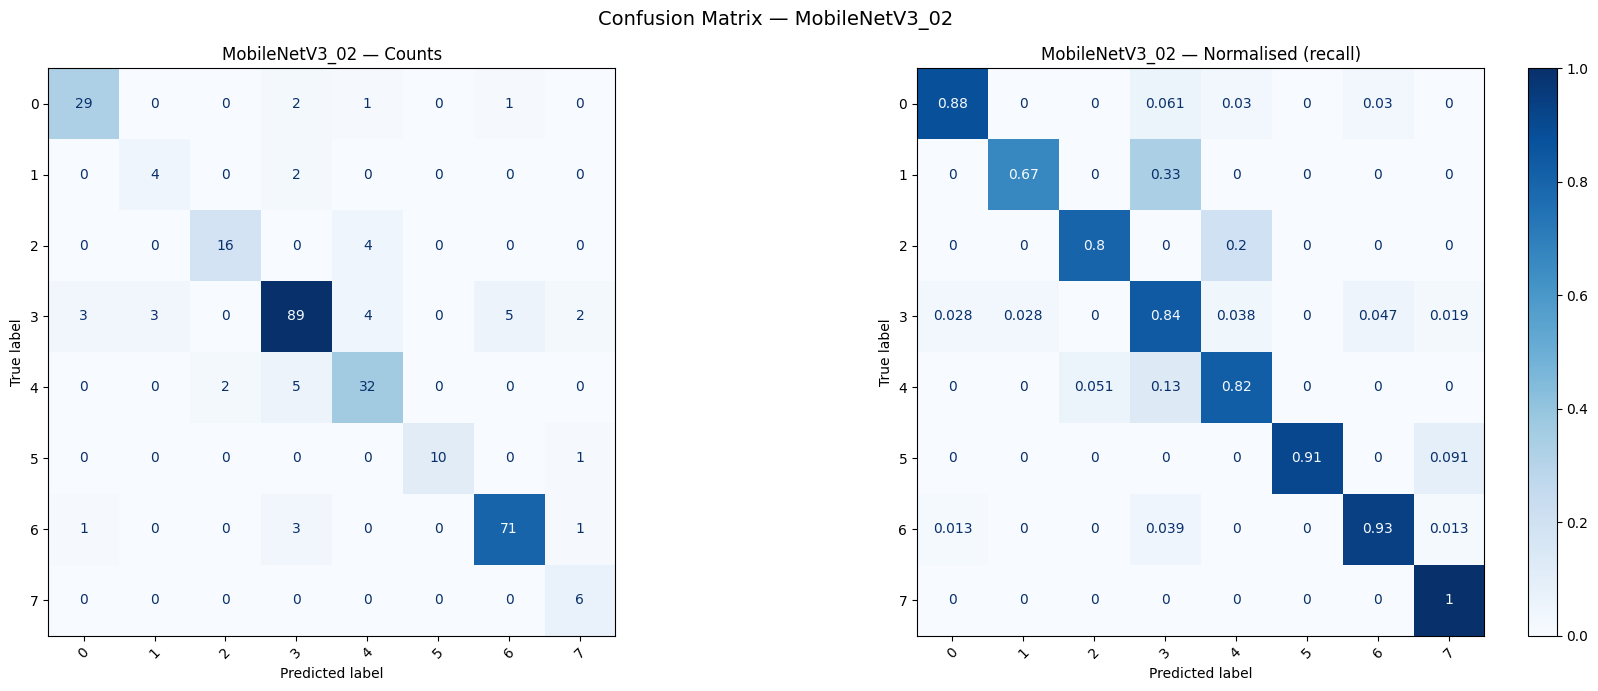

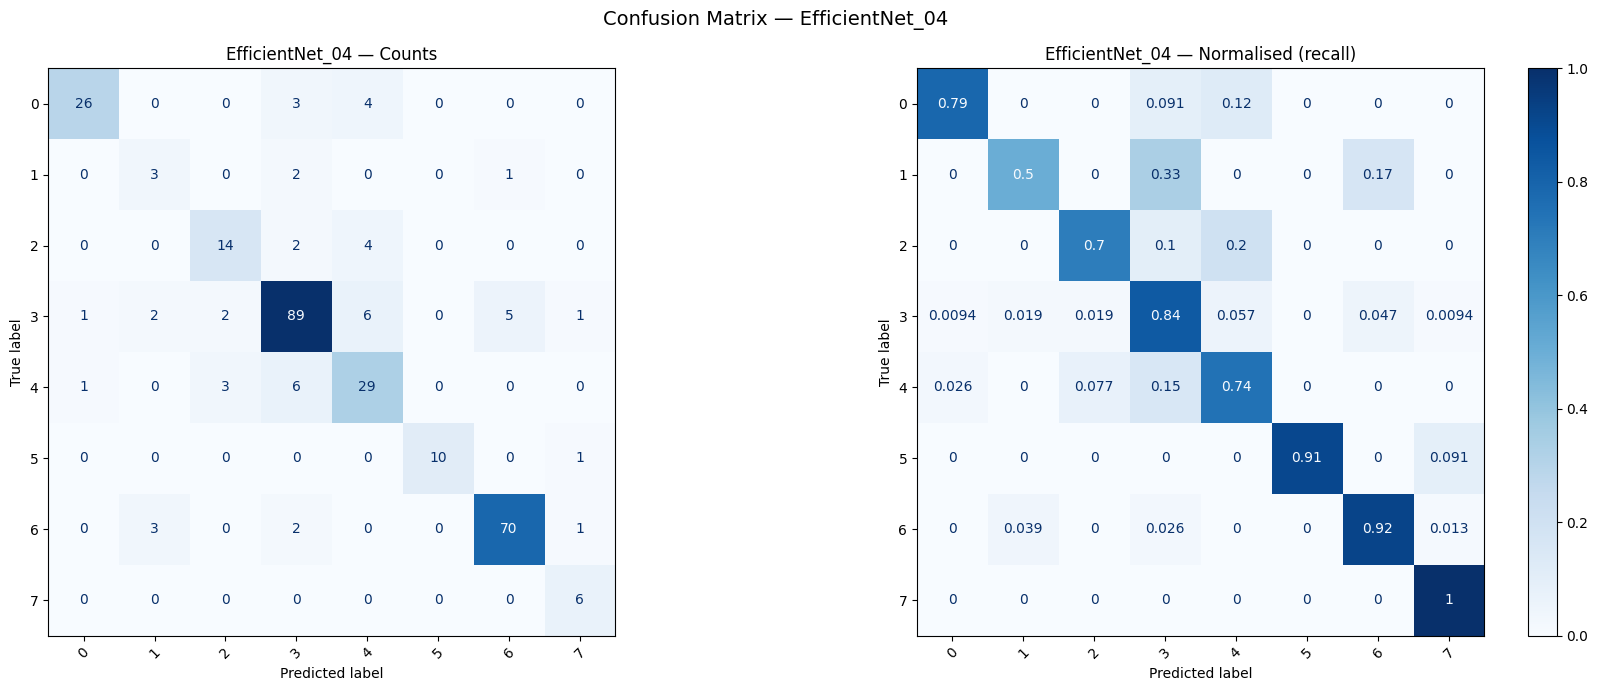

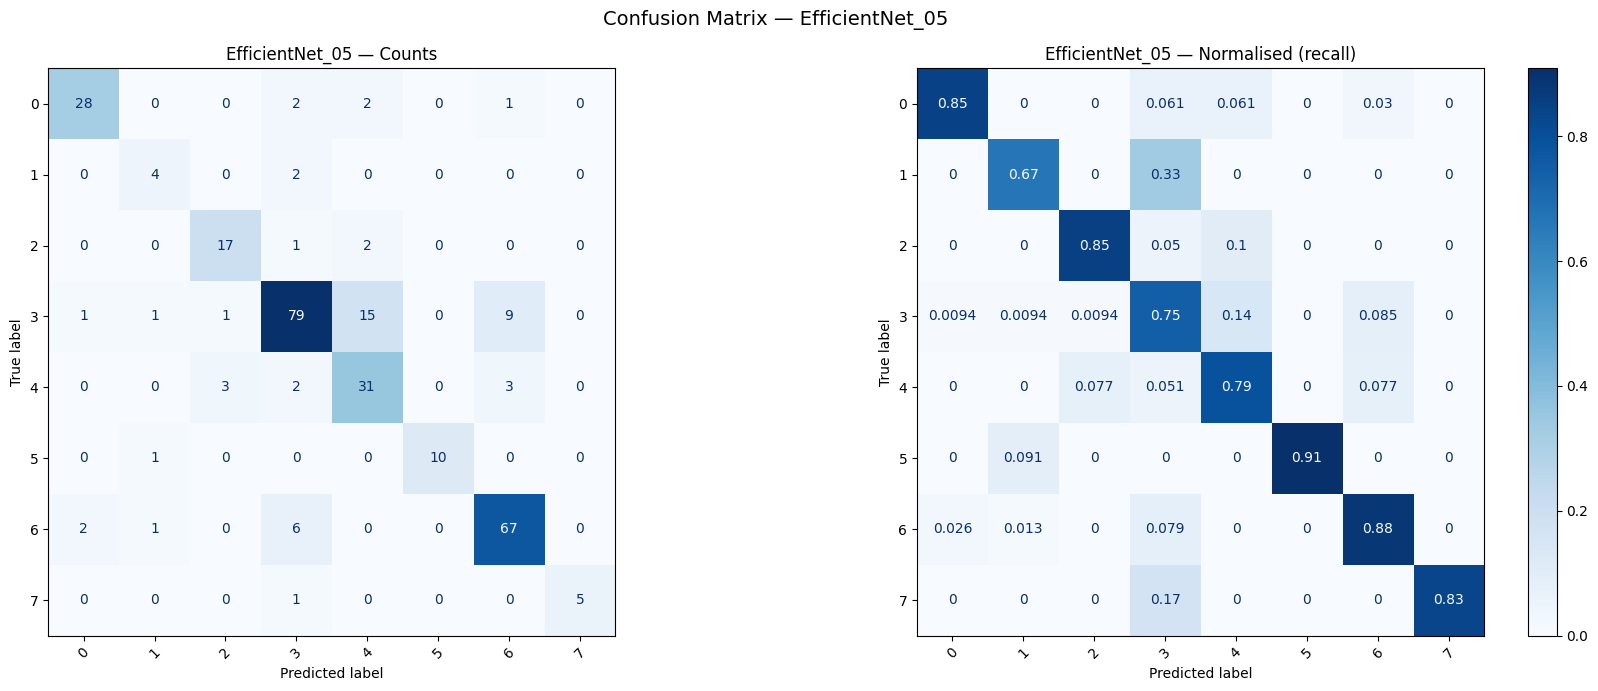

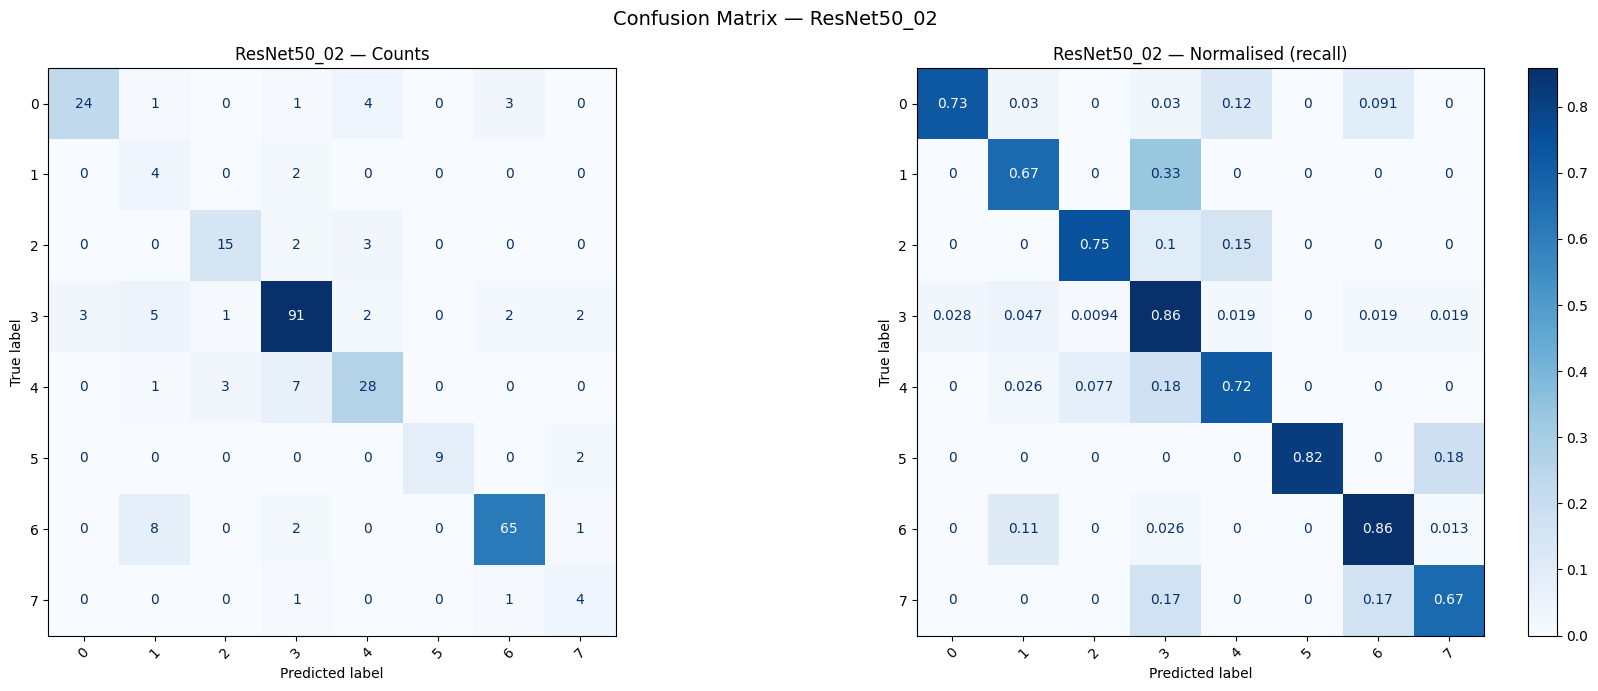

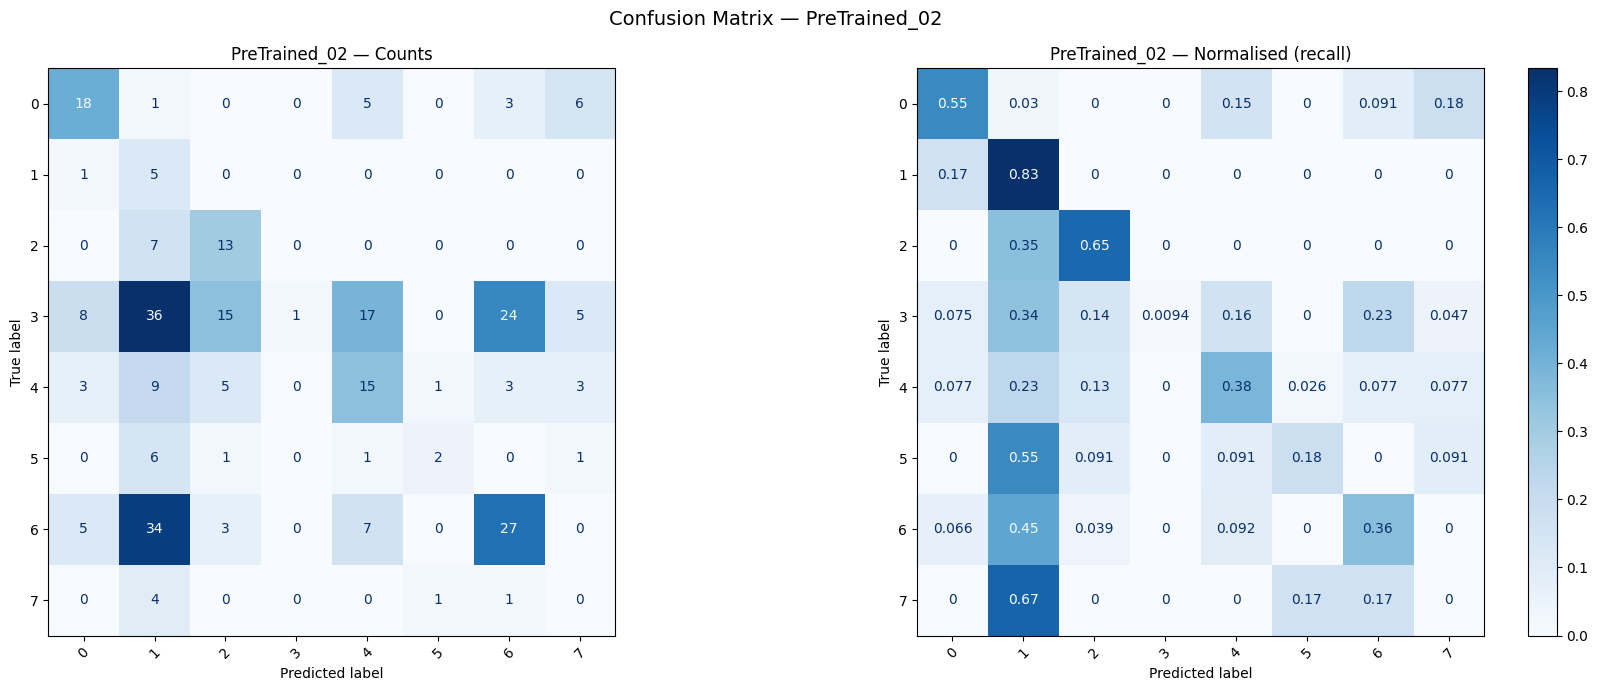

In [9]:
SHORT = [c.split()[0] for c in CLASS_NAMES]

for model_name, m in results.items():
    cm = m["confusion_matrix"]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))

    ConfusionMatrixDisplay(cm, display_labels=SHORT).plot(
        ax=axes[0], cmap="Blues", colorbar=False, xticks_rotation=45)
    axes[0].set_title(f"{model_name} — Counts")

    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True).clip(min=1)
    ConfusionMatrixDisplay(cm_norm, display_labels=SHORT).plot(
        ax=axes[1], cmap="Blues", colorbar=True, xticks_rotation=45)
    axes[1].set_title(f"{model_name} — Normalised (recall)")

    fig.suptitle(f"Confusion Matrix — {model_name}", fontsize=14)
    fig.tight_layout()
    fig.savefig(EVAL_OUT / f"confusion_matrix_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 7. Per-Class Metrics

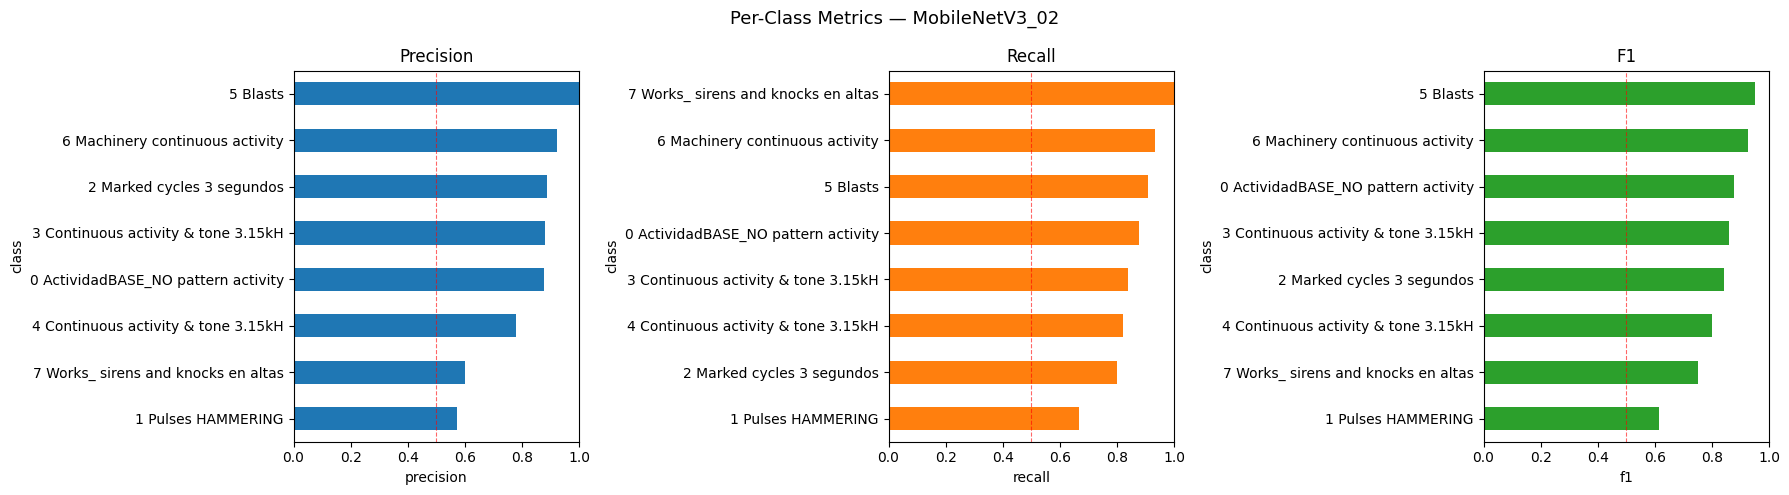

,precision,recall,f1,auc,support
class,,,,,
0 ActividadBASE_NO pattern activity,0.879,0.879,0.879,0.993,33
1 Pulses HAMMERING,0.571,0.667,0.615,0.965,6
2 Marked cycles 3 segundos,0.889,0.800,0.842,0.994,20
3 Continuous activity & tone 3.15kH,0.881,0.840,0.860,0.944,106
4 Continuous activity & tone 3.15kH,0.780,0.821,0.800,0.971,39
5 Blasts,1.000,0.909,0.952,0.999,11
6 Machinery continuous activity,0.922,0.934,0.928,0.956,76
7 Works_ sirens and knocks en altas,0.600,1.000,0.750,1.000,6


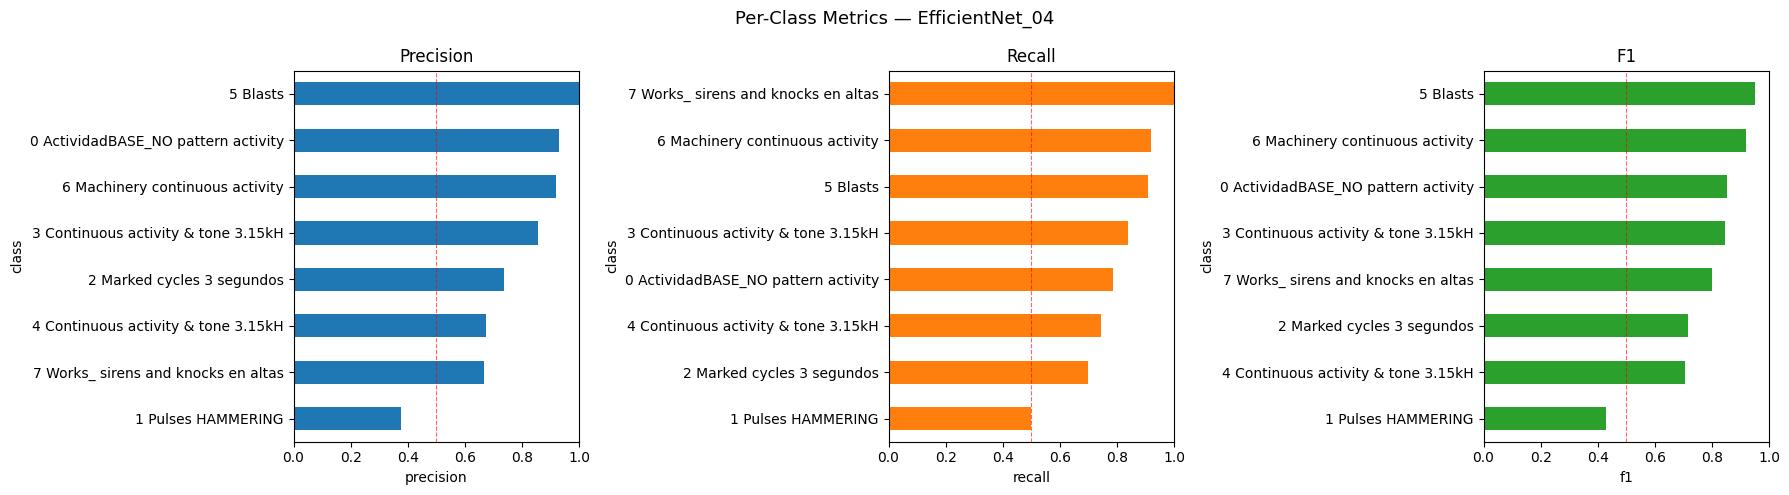

,precision,recall,f1,auc,support
class,,,,,
0 ActividadBASE_NO pattern activity,0.929,0.788,0.852,0.995,33
1 Pulses HAMMERING,0.375,0.500,0.429,0.936,6
2 Marked cycles 3 segundos,0.737,0.700,0.718,0.986,20
3 Continuous activity & tone 3.15kH,0.856,0.840,0.848,0.936,106
4 Continuous activity & tone 3.15kH,0.674,0.744,0.707,0.967,39
5 Blasts,1.000,0.909,0.952,1.000,11
6 Machinery continuous activity,0.921,0.921,0.921,0.974,76
7 Works_ sirens and knocks en altas,0.667,1.000,0.800,0.999,6


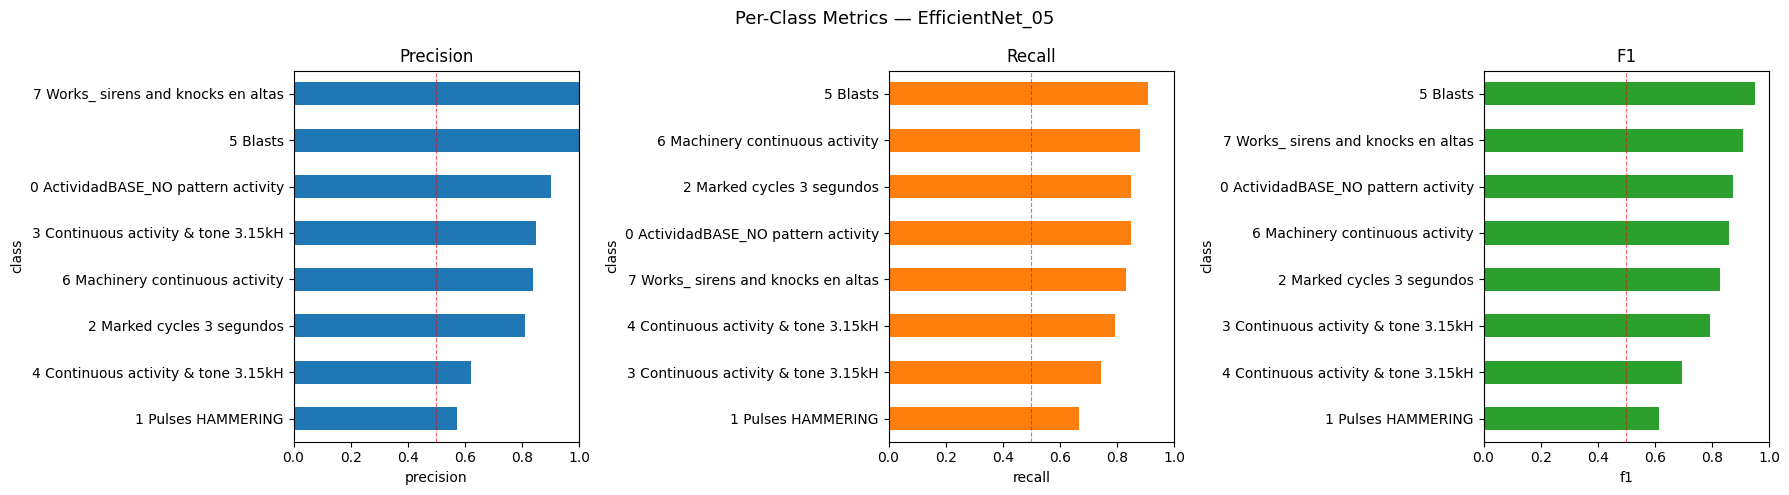

,precision,recall,f1,auc,support
class,,,,,
0 ActividadBASE_NO pattern activity,0.903,0.848,0.875,0.990,33
1 Pulses HAMMERING,0.571,0.667,0.615,0.843,6
2 Marked cycles 3 segundos,0.810,0.850,0.829,0.993,20
3 Continuous activity & tone 3.15kH,0.849,0.745,0.794,0.935,106
4 Continuous activity & tone 3.15kH,0.620,0.795,0.697,0.970,39
5 Blasts,1.000,0.909,0.952,1.000,11
6 Machinery continuous activity,0.838,0.882,0.859,0.975,76
7 Works_ sirens and knocks en altas,1.000,0.833,0.909,0.997,6


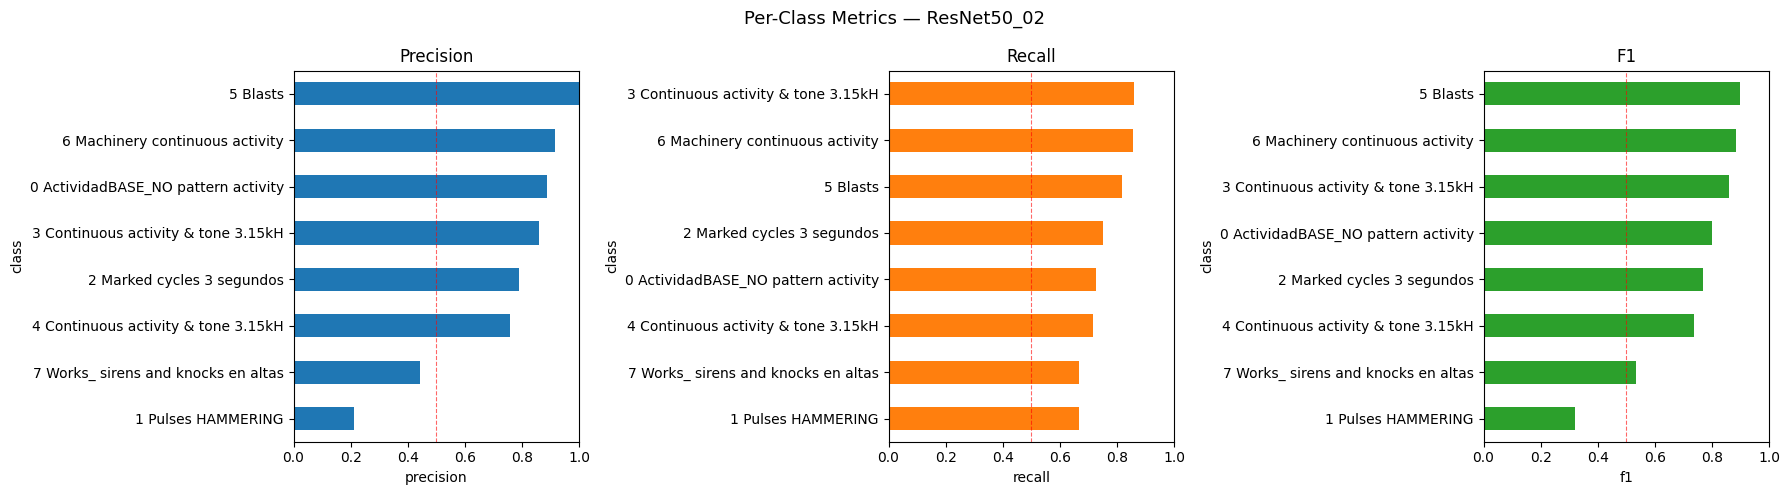

,precision,recall,f1,auc,support
class,,,,,
0 ActividadBASE_NO pattern activity,0.889,0.727,0.800,0.987,33
1 Pulses HAMMERING,0.211,0.667,0.320,0.956,6
2 Marked cycles 3 segundos,0.789,0.750,0.769,0.993,20
3 Continuous activity & tone 3.15kH,0.858,0.858,0.858,0.946,106
4 Continuous activity & tone 3.15kH,0.757,0.718,0.737,0.970,39
5 Blasts,1.000,0.818,0.900,0.916,11
6 Machinery continuous activity,0.915,0.855,0.884,0.956,76
7 Works_ sirens and knocks en altas,0.444,0.667,0.533,0.983,6


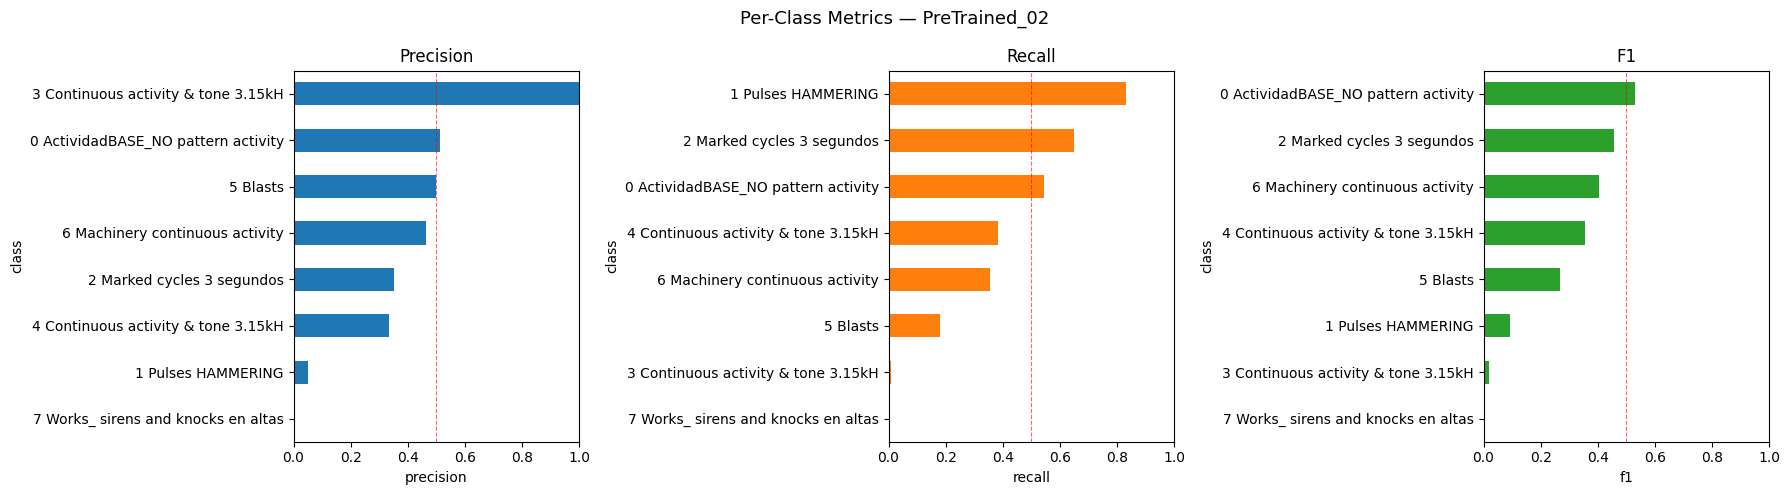

,precision,recall,f1,auc,support
class,,,,,
0 ActividadBASE_NO pattern activity,0.514,0.545,0.529,0.893,33
1 Pulses HAMMERING,0.049,0.833,0.093,0.802,6
2 Marked cycles 3 segundos,0.351,0.650,0.456,0.887,20
3 Continuous activity & tone 3.15kH,1.000,0.009,0.019,0.666,106
4 Continuous activity & tone 3.15kH,0.333,0.385,0.357,0.652,39
5 Blasts,0.500,0.182,0.267,0.763,11
6 Machinery continuous activity,0.466,0.355,0.403,0.709,76
7 Works_ sirens and knocks en altas,0.000,0.000,0.000,0.226,6


In [10]:
for model_name, m in results.items():
    df = m["per_class"].copy()
    df["class"] = df["class"].str[:35]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for ax, col, color in zip(axes, ["precision", "recall", "f1"], ["C0", "C1", "C2"]):
        df.sort_values(col).plot.barh(x="class", y=col, ax=ax, color=color, legend=False)
        ax.set_xlim(0, 1); ax.set_xlabel(col); ax.set_title(col.capitalize())
        ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.6)

    fig.suptitle(f"Per-Class Metrics — {model_name}", fontsize=13)
    fig.tight_layout()
    fig.savefig(EVAL_OUT / f"per_class_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()
    display(df.set_index("class").round(3))

## 8. Model Comparison — F1 per Class

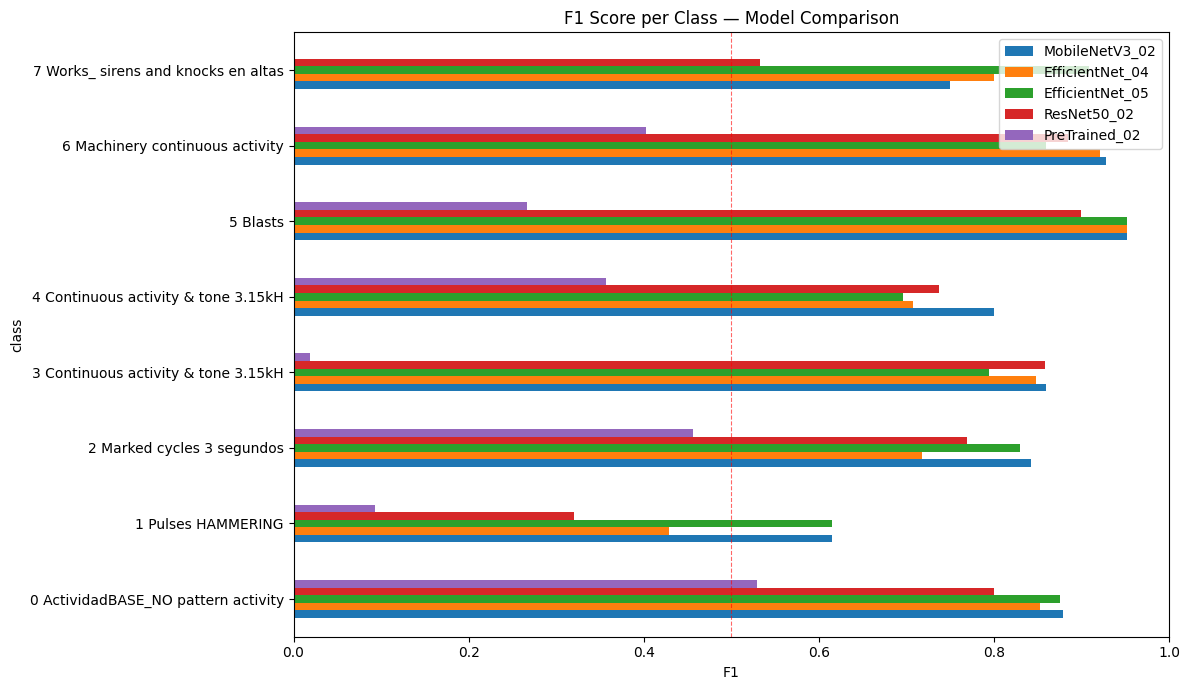

In [11]:
f1_compare = pd.DataFrame(
    {name: m["per_class"].set_index("class")["f1"] for name, m in results.items()}
)
f1_compare.index = f1_compare.index.str[:35]

ax = f1_compare.plot.barh(figsize=(12, 7))
ax.set_xlim(0, 1)
ax.axvline(0.5, color="red", linestyle="--", linewidth=0.8, alpha=0.6)
ax.set_title("F1 Score per Class — Model Comparison")
ax.set_xlabel("F1")
plt.tight_layout()
plt.savefig(EVAL_OUT / "f1_comparison_per_class.png", dpi=150, bbox_inches="tight")
plt.show()

## 8b. Per-Class F1 Heatmap — all models at a glance

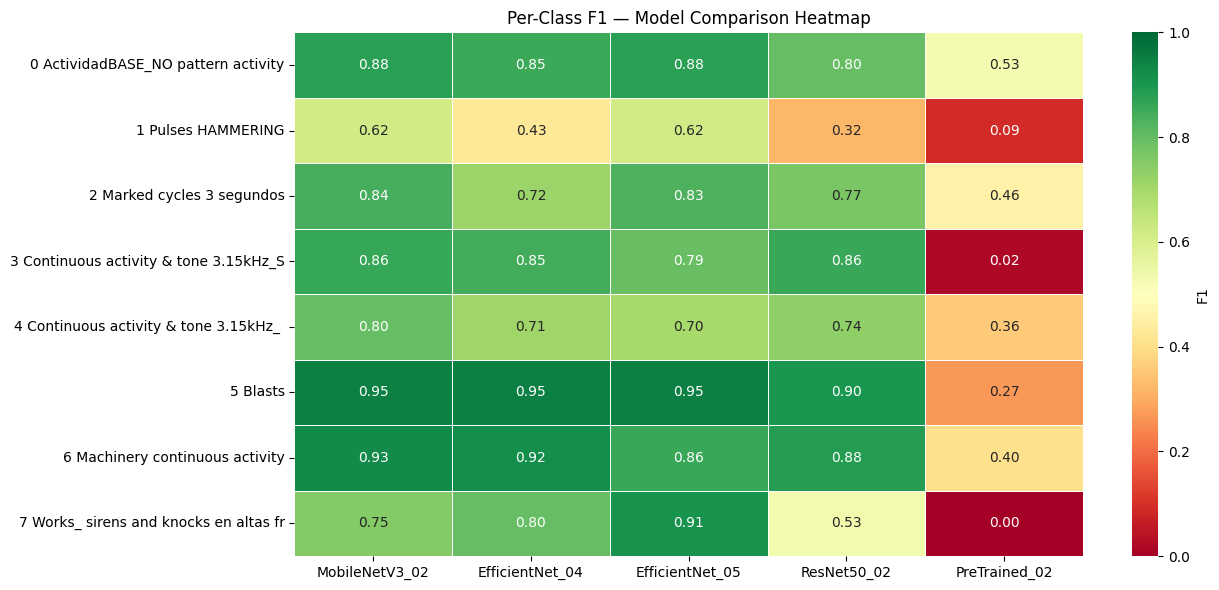

F1 delta vs best model (MobileNetV3_02):


,EfficientNet_04,EfficientNet_05,ResNet50_02,PreTrained_02
0 ActividadBASE_NO pattern activity,-0.026,-0.004,-0.079,-0.349
1 Pulses HAMMERING,-0.187,0.000,-0.295,-0.523
2 Marked cycles 3 segundos,-0.124,-0.013,-0.073,-0.386
3 Continuous activity & tone 3.15kHz_S,-0.012,-0.066,-0.001,-0.841
4 Continuous activity & tone 3.15kHz_,-0.093,-0.103,-0.063,-0.443
5 Blasts,0.000,0.000,-0.052,-0.686
6 Machinery continuous activity,-0.007,-0.069,-0.044,-0.525
7 Works_ sirens and knocks en altas fr,0.050,0.159,-0.217,-0.750


In [12]:
# Rows = classes, columns = models. Green = good, red = bad.
# The fastest way to spot which classes are universally hard vs model-specific failures.
heat = pd.DataFrame(
    {name: m["per_class"].set_index("class")["f1"] for name, m in results.items()}
)
heat.index = [c[:38] for c in heat.index]

fig, ax = plt.subplots(figsize=(2 + 2.2 * len(results), 6))
sns.heatmap(
    heat, annot=True, fmt=".2f", cmap="RdYlGn", vmin=0, vmax=1,
    linewidths=0.5, cbar_kws={"label": "F1"}, ax=ax,
)
ax.set_title("Per-Class F1 — Model Comparison Heatmap")
ax.set_xlabel(""); ax.set_ylabel("")
plt.tight_layout()
plt.savefig(EVAL_OUT / "f1_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

# Delta vs the best model — where does each model lose ground?
best_name = summary.index[0]
print(f"F1 delta vs best model ({best_name}):")
display((heat.sub(heat[best_name], axis=0)).drop(columns=[best_name]).round(3))

## 8c. ROC Curves (one-vs-rest)

One subplot per model, one curve per class. A curve hugging the top-left corner = that class is well separated by the model's probability scores, even if the final argmax prediction is wrong. Useful for spotting classes where the model is "almost right" (good AUC, bad F1) — those are fixable with threshold/calibration work, unlike classes with bad AUC which need better features.

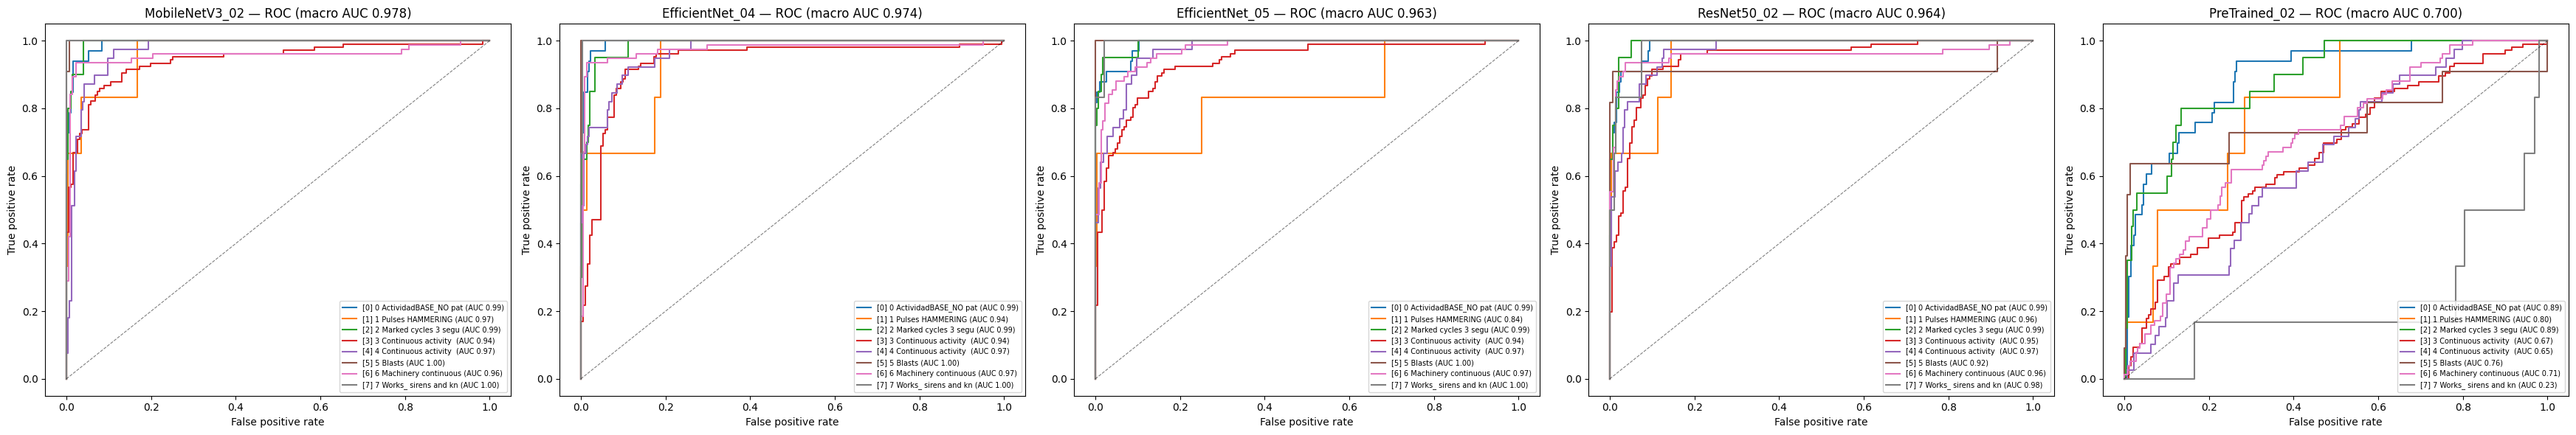

In [13]:
from sklearn.metrics import roc_curve

n_models = len(results)
fig, axes = plt.subplots(1, n_models, figsize=(7 * n_models, 6), squeeze=False)

for ax, (model_name, m) in zip(axes[0], results.items()):
    y_bin = label_binarize(m["y_true"], classes=range(NUM_CLASSES))
    for i in range(NUM_CLASSES):
        if y_bin[:, i].sum() == 0:
            continue
        fpr, tpr, _ = roc_curve(y_bin[:, i], m["y_probs"][:, i])
        auc_i = m["per_class"]["auc"].iloc[i]
        ax.plot(fpr, tpr, label=f"[{i}] {CLASS_NAMES[i][:22]} (AUC {auc_i:.2f})", linewidth=1.5)
    ax.plot([0, 1], [0, 1], "k--", linewidth=0.8, alpha=0.5)
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(f"{model_name} — ROC (macro AUC {m['roc_auc_macro']:.3f})")
    ax.legend(fontsize=7, loc="lower right")

fig.tight_layout()
fig.savefig(EVAL_OUT / "roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 9. Confidence Distribution

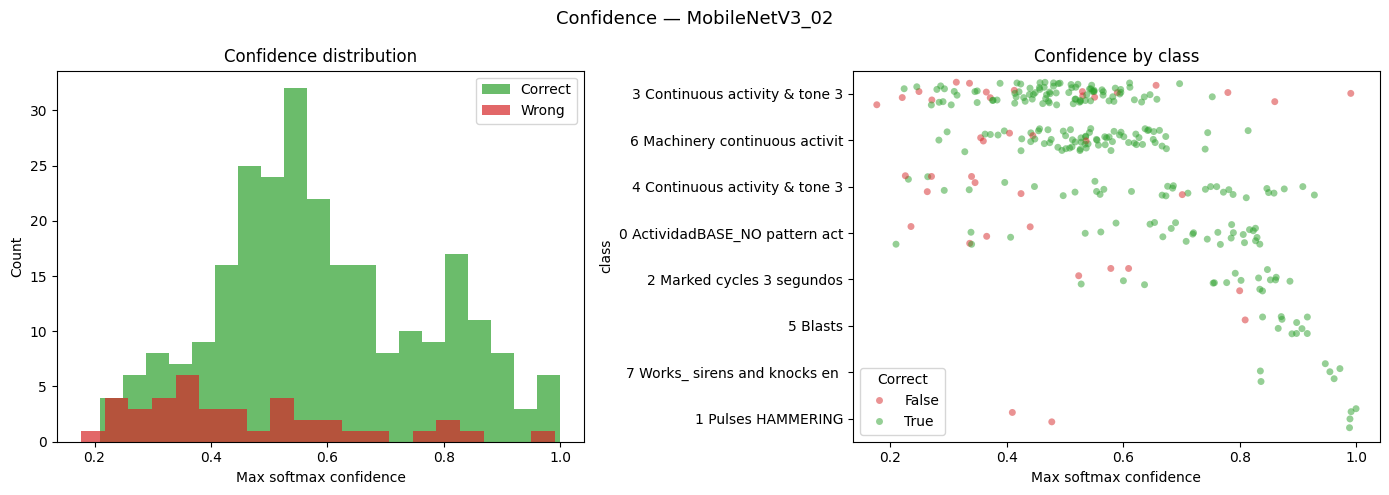

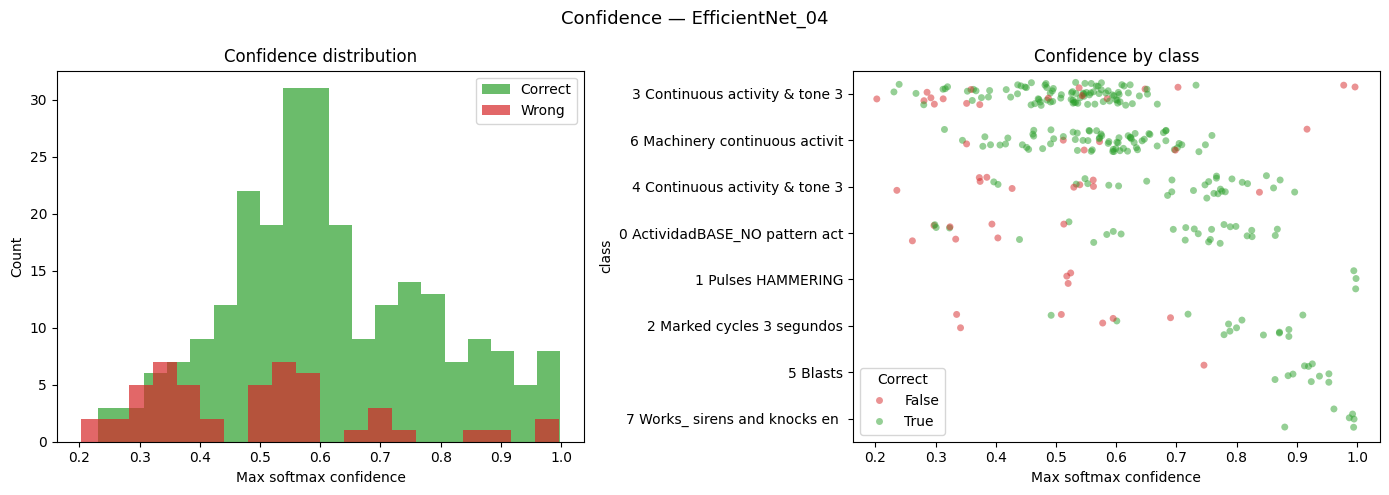

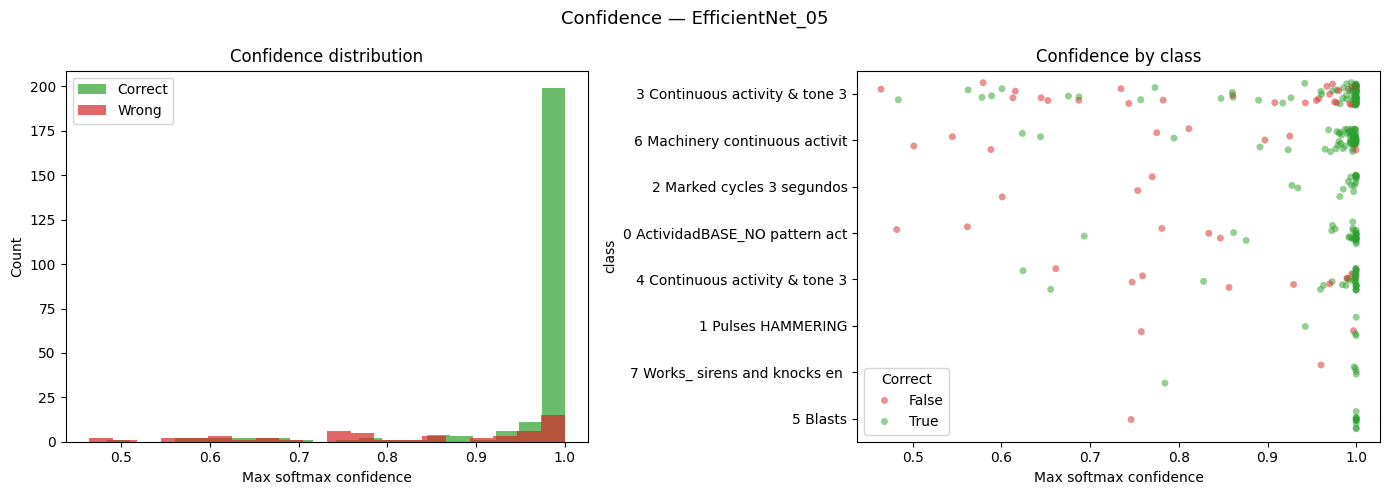

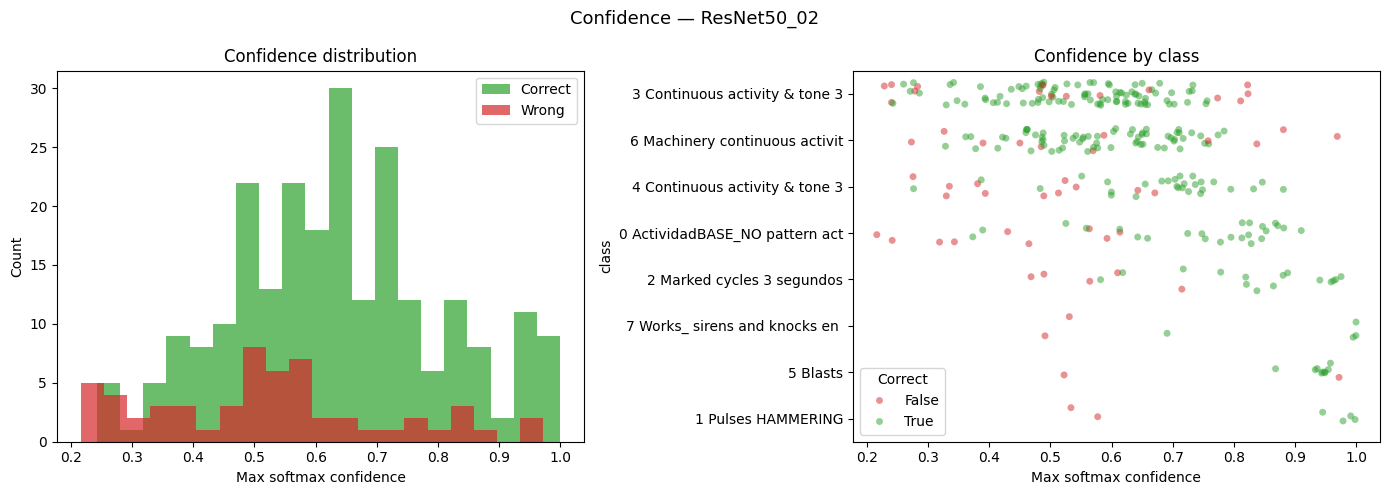

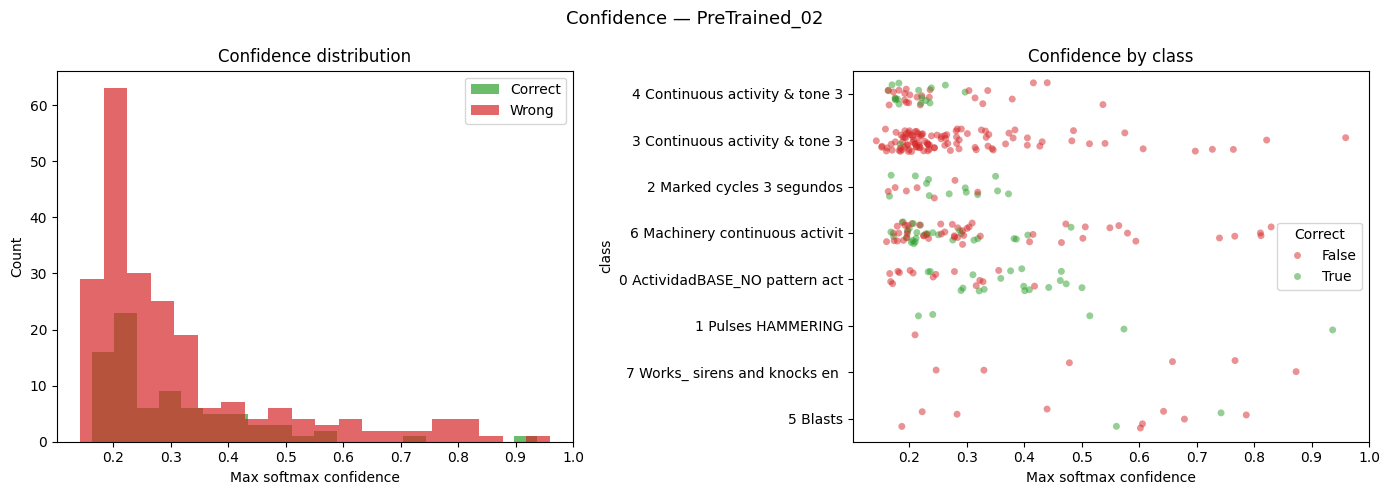

In [14]:
for model_name, m in results.items():
    y_true, y_pred, y_probs = m["y_true"], m["y_pred"], m["y_probs"]
    max_conf = y_probs.max(axis=1)
    correct  = y_true == y_pred

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].hist(max_conf[correct],  bins=20, alpha=0.7, label="Correct", color="C2")
    axes[0].hist(max_conf[~correct], bins=20, alpha=0.7, label="Wrong",   color="C3")
    axes[0].set_xlabel("Max softmax confidence"); axes[0].set_ylabel("Count")
    axes[0].set_title("Confidence distribution"); axes[0].legend()

    df_conf = pd.DataFrame({
        "class":      [CLASS_NAMES[i][:30] for i in y_true],
        "confidence": max_conf,
        "correct":    correct,
    })
    class_order = df_conf.groupby("class")["confidence"].median().sort_values().index.tolist()
    sns.stripplot(
        data=df_conf, y="class", x="confidence", hue="correct",
        order=class_order, dodge=False, alpha=0.5, jitter=0.25,
        palette={True: "C2", False: "C3"}, ax=axes[1],
    )
    axes[1].set_title("Confidence by class"); axes[1].set_xlabel("Max softmax confidence")
    axes[1].legend(title="Correct")

    fig.suptitle(f"Confidence — {model_name}", fontsize=13)
    fig.tight_layout()
    fig.savefig(EVAL_OUT / f"confidence_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.show()

## 10. Learning Curves

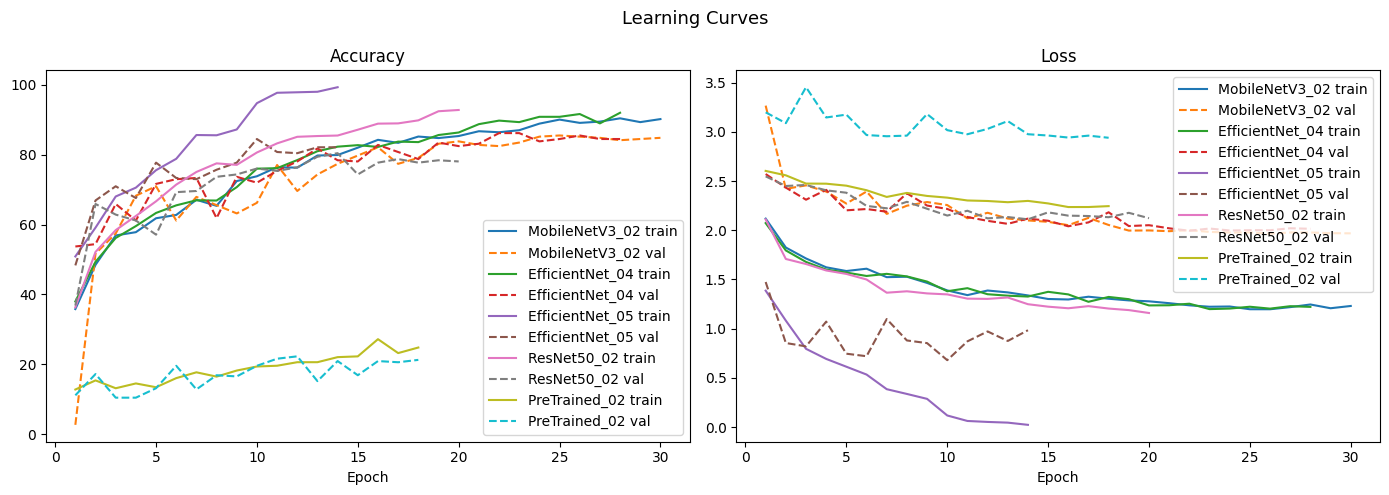

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for model_name, hist_path in HISTORIES.items():
    if not hist_path.exists():
        print(f"  History not found: {hist_path.name}")
        continue
    df = pd.read_csv(hist_path)
    acc_col = "train_acc" if "train_acc" in df.columns else "train_accuracy"
    val_col = "val_acc"   if "val_acc"   in df.columns else "val_accuracy"
    axes[0].plot(df["epoch"], df[acc_col],      label=f"{model_name} train")
    axes[0].plot(df["epoch"], df[val_col],      label=f"{model_name} val",   linestyle="--")
    axes[1].plot(df["epoch"], df["train_loss"], label=f"{model_name} train")
    axes[1].plot(df["epoch"], df["val_loss"],   label=f"{model_name} val",   linestyle="--")

axes[0].set_title("Accuracy"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].set_title("Loss");     axes[1].set_xlabel("Epoch"); axes[1].legend()
fig.suptitle("Learning Curves", fontsize=13)
fig.tight_layout()
fig.savefig(EVAL_OUT / "learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Misclassification Analysis

In [16]:
for model_name, m in results.items():
    y_true, y_pred, y_probs = m["y_true"], m["y_pred"], m["y_probs"]
    mask = y_true != y_pred
    df_mis = pd.DataFrame({
        "true":       [CLASS_NAMES[i][:40] for i in y_true[mask]],
        "predicted":  [CLASS_NAMES[i][:40] for i in y_pred[mask]],
        "confidence": y_probs[mask].max(axis=1).round(3),
    })
    top = (
        df_mis.groupby(["true", "predicted"]).size()
        .reset_index(name="count").sort_values("count", ascending=False).head(10)
    )
    print(f"\n{'='*60}")
    print(f"{model_name} — {mask.sum()} misclassified / {len(y_true)}")
    print(f"{'='*60}")
    display(top.reset_index(drop=True))
    df_mis.to_csv(EVAL_OUT / f"misclassified_{model_name}.csv", index=False)


MobileNetV3_02 — 40 misclassified / 297


,true,predicted,count
0,4 Continuous activity & tone 3.15kHz_ SP,3 Continuous activity & tone 3.15kHz_SPL,5
1,3 Continuous activity & tone 3.15kHz_SPL,6 Machinery continuous activity,5
2,3 Continuous activity & tone 3.15kHz_SPL,4 Continuous activity & tone 3.15kHz_ SP,4
3,2 Marked cycles 3 segundos,4 Continuous activity & tone 3.15kHz_ SP,4
4,3 Continuous activity & tone 3.15kHz_SPL,1 Pulses HAMMERING,3
5,6 Machinery continuous activity,3 Continuous activity & tone 3.15kHz_SPL,3
6,3 Continuous activity & tone 3.15kHz_SPL,0 ActividadBASE_NO pattern activity,3
7,1 Pulses HAMMERING,3 Continuous activity & tone 3.15kHz_SPL,2
8,4 Continuous activity & tone 3.15kHz_ SP,2 Marked cycles 3 segundos,2
9,3 Continuous activity & tone 3.15kHz_SPL,7 Works_ sirens and knocks en altas frec,2



EfficientNet_04 — 50 misclassified / 297


,true,predicted,count
0,3 Continuous activity & tone 3.15kHz_SPL,4 Continuous activity & tone 3.15kHz_ SP,6
1,4 Continuous activity & tone 3.15kHz_ SP,3 Continuous activity & tone 3.15kHz_SPL,6
2,3 Continuous activity & tone 3.15kHz_SPL,6 Machinery continuous activity,5
3,0 ActividadBASE_NO pattern activity,4 Continuous activity & tone 3.15kHz_ SP,4
4,2 Marked cycles 3 segundos,4 Continuous activity & tone 3.15kHz_ SP,4
5,4 Continuous activity & tone 3.15kHz_ SP,2 Marked cycles 3 segundos,3
6,0 ActividadBASE_NO pattern activity,3 Continuous activity & tone 3.15kHz_SPL,3
7,6 Machinery continuous activity,1 Pulses HAMMERING,3
8,1 Pulses HAMMERING,3 Continuous activity & tone 3.15kHz_SPL,2
9,3 Continuous activity & tone 3.15kHz_SPL,2 Marked cycles 3 segundos,2



EfficientNet_05 — 56 misclassified / 297


,true,predicted,count
0,3 Continuous activity & tone 3.15kHz_SPL,4 Continuous activity & tone 3.15kHz_ SP,15
1,3 Continuous activity & tone 3.15kHz_SPL,6 Machinery continuous activity,9
2,6 Machinery continuous activity,3 Continuous activity & tone 3.15kHz_SPL,6
3,4 Continuous activity & tone 3.15kHz_ SP,6 Machinery continuous activity,3
4,4 Continuous activity & tone 3.15kHz_ SP,2 Marked cycles 3 segundos,3
5,0 ActividadBASE_NO pattern activity,3 Continuous activity & tone 3.15kHz_SPL,2
6,0 ActividadBASE_NO pattern activity,4 Continuous activity & tone 3.15kHz_ SP,2
7,6 Machinery continuous activity,0 ActividadBASE_NO pattern activity,2
8,4 Continuous activity & tone 3.15kHz_ SP,3 Continuous activity & tone 3.15kHz_SPL,2
9,1 Pulses HAMMERING,3 Continuous activity & tone 3.15kHz_SPL,2



ResNet50_02 — 57 misclassified / 297


,true,predicted,count
0,6 Machinery continuous activity,1 Pulses HAMMERING,8
1,4 Continuous activity & tone 3.15kHz_ SP,3 Continuous activity & tone 3.15kHz_SPL,7
2,3 Continuous activity & tone 3.15kHz_SPL,1 Pulses HAMMERING,5
3,0 ActividadBASE_NO pattern activity,4 Continuous activity & tone 3.15kHz_ SP,4
4,2 Marked cycles 3 segundos,4 Continuous activity & tone 3.15kHz_ SP,3
5,0 ActividadBASE_NO pattern activity,6 Machinery continuous activity,3
6,3 Continuous activity & tone 3.15kHz_SPL,0 ActividadBASE_NO pattern activity,3
7,4 Continuous activity & tone 3.15kHz_ SP,2 Marked cycles 3 segundos,3
8,2 Marked cycles 3 segundos,3 Continuous activity & tone 3.15kHz_SPL,2
9,1 Pulses HAMMERING,3 Continuous activity & tone 3.15kHz_SPL,2



PreTrained_02 — 216 misclassified / 297


,true,predicted,count
0,3 Continuous activity & tone 3.15kHz_SPL,1 Pulses HAMMERING,36
1,6 Machinery continuous activity,1 Pulses HAMMERING,34
2,3 Continuous activity & tone 3.15kHz_SPL,6 Machinery continuous activity,24
3,3 Continuous activity & tone 3.15kHz_SPL,4 Continuous activity & tone 3.15kHz_ SP,17
4,3 Continuous activity & tone 3.15kHz_SPL,2 Marked cycles 3 segundos,15
5,4 Continuous activity & tone 3.15kHz_ SP,1 Pulses HAMMERING,9
6,3 Continuous activity & tone 3.15kHz_SPL,0 ActividadBASE_NO pattern activity,8
7,2 Marked cycles 3 segundos,1 Pulses HAMMERING,7
8,6 Machinery continuous activity,4 Continuous activity & tone 3.15kHz_ SP,7
9,5 Blasts,1 Pulses HAMMERING,6


## 11b. Model Agreement — universally hard samples

Samples that **every** model misclassifies are likely label noise, corrupted spectrograms, or genuinely ambiguous audio — worth listening to manually. Samples where models disagree show where an ensemble could help.

In [17]:
# Compare only models worth comparing (skip anything below 40% accuracy — collapsed runs distort this)
good_models = {n: m for n, m in results.items() if m["accuracy"] >= 0.40}
print(f"Models included: {list(good_models.keys())}")
print(f"(excluded as collapsed/broken: {[n for n in results if n not in good_models]})\n")

if len(good_models) >= 2:
    names = list(good_models.keys())
    y_true = good_models[names[0]]["y_true"]
    correct_matrix = np.stack(
        [good_models[n]["y_pred"] == y_true for n in names]
    )  # [n_models, n_samples] bool

    n_correct_per_sample = correct_matrix.sum(axis=0)
    all_wrong  = n_correct_per_sample == 0
    all_right  = n_correct_per_sample == len(names)
    disagree   = ~all_wrong & ~all_right

    print(f"Test samples          : {len(y_true)}")
    print(f"All models correct    : {all_right.sum():4d}  ({100*all_right.mean():.1f}%)")
    print(f"Models disagree       : {disagree.sum():4d}  ({100*disagree.mean():.1f}%)  ← ensemble potential")
    print(f"All models wrong      : {all_wrong.sum():4d}  ({100*all_wrong.mean():.1f}%)  ← check these manually")

    # File names of universally-failed samples (from the dataset ordering, shuffle=False for test)
    sample_paths = [Path(p).name for (p, _) in test_loader.dataset.samples]
    df_hard = pd.DataFrame({
        "file":  [sample_paths[i] for i in np.where(all_wrong)[0]],
        "true":  [CLASS_NAMES[y_true[i]][:40] for i in np.where(all_wrong)[0]],
        **{
            n: [CLASS_NAMES[good_models[n]["y_pred"][i]][:25] for i in np.where(all_wrong)[0]]
            for n in names
        },
    })
    print("\nUniversally misclassified samples:")
    display(df_hard)
    df_hard.to_csv(EVAL_OUT / "universally_hard_samples.csv", index=False)

    # Oracle ensemble ceiling: accuracy if we could always pick the right model
    oracle_acc = (n_correct_per_sample > 0).mean()
    best_single = max(m["accuracy"] for m in good_models.values())
    print(f"\nBest single model accuracy : {best_single:.4f}")
    print(f"Oracle ensemble ceiling    : {oracle_acc:.4f}  (+{100*(oracle_acc-best_single):.1f} pts available from ensembling)")
else:
    print("Need at least 2 working models for agreement analysis.")

Models included: ['MobileNetV3_02', 'EfficientNet_04', 'EfficientNet_05', 'ResNet50_02']
(excluded as collapsed/broken: ['PreTrained_02'])

Test samples          : 297
All models correct    :  199  (67.0%)
Models disagree       :   75  (25.3%)  ← ensemble potential
All models wrong      :   23  (7.7%)  ← check these manually

Universally misclassified samples:


,file,true,MobileNetV3_02,EfficientNet_04,EfficientNet_05,ResNet50_02
0,SM301165__0__20161001_053401_3.wav.norm.pt,0 ActividadBASE_NO pattern activity,3 Continuous activity & t,4 Continuous activity & t,4 Continuous activity & t,4 Continuous activity & t
1,SM301602__0__20161002_223801_3.wav.norm.pt,0 ActividadBASE_NO pattern activity,4 Continuous activity & t,4 Continuous activity & t,4 Continuous activity & t,1 Pulses HAMMERING
2,SM301602__0__20161002_232201_1.wav.norm.pt,0 ActividadBASE_NO pattern activity,6 Machinery continuous ac,3 Continuous activity & t,3 Continuous activity & t,3 Continuous activity & t
3,SM301165__0__20161005_225201_1.wav.norm.pt,1 Pulses HAMMERING,3 Continuous activity & t,3 Continuous activity & t,3 Continuous activity & t,3 Continuous activity & t
4,SM301165__0__20161005_225201_2.wav.norm.pt,1 Pulses HAMMERING,3 Continuous activity & t,3 Continuous activity & t,3 Continuous activity & t,3 Continuous activity & t
5,SM301165__0__20161004_171001_3.wav.norm.pt,2 Marked cycles 3 segundos,4 Continuous activity & t,4 Continuous activity & t,4 Continuous activity & t,4 Continuous activity & t
6,SM301165__0__20161001_140001_3.wav.norm.pt,3 Continuous activity & tone 3.15kHz_SPL,6 Machinery continuous ac,6 Machinery continuous ac,6 Machinery continuous ac,0 ActividadBASE_NO patter
7,SM301165__0__20161001_233201_3.wav.norm.pt,3 Continuous activity & tone 3.15kHz_SPL,6 Machinery continuous ac,6 Machinery continuous ac,6 Machinery continuous ac,4 Continuous activity & t
8,SM301165__0__20161002_135001_3.wav.norm.pt,3 Continuous activity & tone 3.15kHz_SPL,7 Works_ sirens and knock,7 Works_ sirens and knock,6 Machinery continuous ac,7 Works_ sirens and knock
9,SM301165__0__20161004_065401_1.wav.norm.pt,3 Continuous activity & tone 3.15kHz_SPL,1 Pulses HAMMERING,1 Pulses HAMMERING,1 Pulses HAMMERING,1 Pulses HAMMERING



Best single model accuracy : 0.8653
Oracle ensemble ceiling    : 0.9226  (+5.7 pts available from ensembling)


## 12. Classification Report (Full)

In [18]:
for model_name, m in results.items():
    print(f"\n{'='*60}")
    print(f"Classification Report — {model_name}")
    print(f"{'='*60}")
    print(classification_report(m["y_true"], m["y_pred"], target_names=CLASS_NAMES, zero_division=0))


Classification Report — MobileNetV3_02
                                                                precision    recall  f1-score   support

                           0 ActividadBASE_NO pattern activity       0.88      0.88      0.88        33
                                            1 Pulses HAMMERING       0.57      0.67      0.62         6
                                    2 Marked cycles 3 segundos       0.89      0.80      0.84        20
                 3 Continuous activity & tone 3.15kHz_SPL ALTO       0.88      0.84      0.86       106
                4 Continuous activity & tone 3.15kHz_ SPL BAJO       0.78      0.82      0.80        39
                                                      5 Blasts       1.00      0.91      0.95        11
                               6 Machinery continuous activity       0.92      0.93      0.93        76
7 Works_ sirens and knocks en altas frecuencias RAFAGAS a 3.15       0.60      1.00      0.75         6

                      

## 13. Save Summary CSV

In [19]:
summary.to_csv(EVAL_OUT / "summary_metrics.csv")
print(f"Saved to {EVAL_OUT}")
for f in sorted(EVAL_OUT.iterdir()):
    if f.is_file():
        print(f"  {f.name}")

Saved to D:\Work\Internships\INMAR\REPSOL\outputs\evaluation
  all_runs_comparison.png
  all_runs_summary.csv
  confidence_EfficientNet_01.png
  confidence_EfficientNet_02.png
  confidence_EfficientNet_04.png
  confidence_EfficientNet_05.png
  confidence_MobileNetV3_02.png
  confidence_PreTrained_01.png
  confidence_PreTrained_02.png
  confidence_ResNet50_01.png
  confidence_ResNet50_02.png
  confusion_matrix_EfficientNet_01.png
  confusion_matrix_EfficientNet_02.png
  confusion_matrix_EfficientNet_04.png
  confusion_matrix_EfficientNet_05.png
  confusion_matrix_MobileNetV3_02.png
  confusion_matrix_PreTrained_01.png
  confusion_matrix_PreTrained_02.png
  confusion_matrix_ResNet50_01.png
  confusion_matrix_ResNet50_02.png
  f1_comparison_per_class.png
  f1_heatmap.png
  learning_curves.png
  learning_curves_efficientnet_04.png
  learning_curves_efficientnet_05.png
  learning_curves_mobilenetv3_02.png
  learning_curves_pretrained_02.png
  learning_curves_resnet50_02.png
  misclassified_

## 14. Verdict & decision guide

### Best model: **MobileNetV3-02** — 86.5% test accuracy, 0.83 macro-F1

Wins or ties on nearly every metric and every class, with the fewest parameters (5.4M) and
the fastest CPU inference of the set. The smallest backbone generalising best is the expected
outcome on 1,382 training images.

### Priority order & when to choose each

| Priority | Model | Test acc / macro-F1 | Choose when |
|---|---|---|---|
| **1** | **MobileNetV3-02** | 86.5% / 0.83 | **Default & deployment.** Pre-labeling unlabeled data, CPU/edge inference. Best overall accuracy AND best balance on the hard classes (class 4 SPL BAJO: 0.80, class 1 Hammering: 0.62). |
| **2** | EfficientNet-04 | 83.2% / 0.78 | Second opinion / soft-voting **ensemble partner** — its errors differ from MobileNet's (best class-7 F1: 0.80). Most stable training recipe → best base for future experiments (e.g. 224×448 higher time-resolution input). |
| **3** | EfficientNet-05 | 81.1% / 0.82 | **Never for deployment — it is the scientific control**: run-02's exact baseline config on fixed data. Use it in the report to isolate the data-fix effect (+13 acc pts with zero tuning) and to show the baseline still overfits (99% train acc by ep14) without the regularisation package. |
| **4** | ResNet50-02 | 80.8% / 0.73 | No deployment scenario: largest model, slowest, lowest macro-F1 of the main four, poor rare-class precision (class 1: 0.21). Keep as the architecture-comparison data point: capacity ≫ data hurts even with layer4-only fine-tuning. |
| — | PreTrained-02 | 27.3% / 0.26 | **Negative result, documentation only.** Watkins warm-start failed: the source model learned librosa grayscale mel-spectrograms — a completely different input distribution than these MATLAB RGB figure renders — so the frozen early features never matched. Generic ImageNet features transfer better than narrow-domain features from a mismatched pipeline. |

### Key findings for the report
1. **The data fix dominated everything.** The identical baseline config went 70% → 81%
   (EfficientNet-02 vs -05) with zero hyperparameter changes. No amount of tuning on broken
   data came close.
2. **The regularisation package buys stability more than raw accuracy** (+2 pts on
   EfficientNet), while **architecture choice** added more (+3.3 pts, MobileNet vs EfficientNet).
3. **Remaining error mass:** class 3↔4 confusion (amplitude-only distinction between the two
   3.15 kHz tone classes) and class 1 (only 30 training samples). Highest-value next steps:
   more data for classes 1 & 7, and/or a 224×448 dataset for better time resolution of
   transients.
4. **Statistical honesty:** per-class F1 for classes 1, 5, 7 rests on 6–11 test samples —
   treat differences there as indicative, not significant. K-fold cross-validation is the
   right tool if a rare-class claim needs defending.
5. **Ensemble headroom:** see the oracle-ensemble ceiling in section 11b — if it is
   meaningfully above the best single model, a MobileNetV3-02 + EfficientNet-04 soft-voting
   ensemble is a cheap accuracy win for offline (non-real-time) batch labeling.